**This notebook consists of EDA of IBM HR Attrition**




1.   Importing libraries and loading dataset into dataframe
2.   Checking no of rows and columns

3.   Taking a sneak peak on the data

1.   Removing irrelevent columns


2.   Checking data type of columns and checking the count of non zero elements in each column


1.   Checking missing/null values
2.   Checking duplicate rows








In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
df = pd.read_csv('D:/IBM HR Attrition/IBM_HR_dataset.csv') # Load dataset into DataFrame


In [2]:
df.shape # Return no of rows and columns

(1470, 35)

In [3]:
df.head() # Have a sneak peak on the dataset

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


Removing irrelevent columns as they are not required.

In [4]:
df = df.drop(columns=['EmployeeCount','EmployeeNumber','StandardHours','Over18','HourlyRate','DailyRate','MonthlyRate'], errors = 'ignore')

In [5]:
df.info() # Getting info about non null/zero values and data types of each column

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 28 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   Department                1470 non-null   str  
 4   DistanceFromHome          1470 non-null   int64
 5   Education                 1470 non-null   int64
 6   EducationField            1470 non-null   str  
 7   EnvironmentSatisfaction   1470 non-null   int64
 8   Gender                    1470 non-null   str  
 9   JobInvolvement            1470 non-null   int64
 10  JobLevel                  1470 non-null   int64
 11  JobRole                   1470 non-null   str  
 12  JobSatisfaction           1470 non-null   int64
 13  MaritalStatus             1470 non-null   str  
 14  MonthlyIncome             1470 non-null   int64
 15

In [6]:
df.duplicated().sum()    # checking duplicate rows

np.int64(0)

In [7]:
df.isna().sum().sum()  # checking missing values

np.int64(0)

We do get that there are no missing values in the dataset as per **.isna()** function. But we also need to make sure that there are no string based placeholders occupying space and as it occupies space as .isna() actually bypasses it and considers as **non_null**. So to counter this issue we use **Type Coercion** for **int** data type columns and **.unique()** for **object** data type columns as we get all the unique entries per column and we identify suspicious placeholders and replace them and this make sure that missing values are completely handled.

In [8]:
# For int data type columns
int_columns = df.select_dtypes(include='int64').columns  #put all numeric columns in one and then check
df[int_columns] = df[int_columns].apply(pd.to_numeric,errors='coerce')
df[int_columns].isna().sum().sum()

np.int64(0)

Now we've checked each numeric column(**int64**) by **type coercion** and got that there are no placeholder missing values and no **NaN** or **Null** values.

In **object** data type based columns there is one issue which still persists and that is of empty string or a space as it is difficult to trace with .unique() so we strip the space with .str.strip() and then we replace it with **NaN** which can be traced by .isna()

In [9]:
# For object data type columns
for col in df.select_dtypes(include='object').columns :
  print(f"\n{col}:")
  print(df[col].unique())


Attrition:
<StringArray>
['Yes', 'No']
Length: 2, dtype: str

BusinessTravel:
<StringArray>
['Travel_Rarely', 'Travel_Frequently', 'Non-Travel']
Length: 3, dtype: str

Department:
<StringArray>
['Sales', 'Research & Development', 'Human Resources']
Length: 3, dtype: str

EducationField:
<StringArray>
[   'Life Sciences',            'Other',          'Medical',
        'Marketing', 'Technical Degree',  'Human Resources']
Length: 6, dtype: str

Gender:
<StringArray>
['Female', 'Male']
Length: 2, dtype: str

JobRole:
<StringArray>
[          'Sales Executive',        'Research Scientist',
     'Laboratory Technician',    'Manufacturing Director',
 'Healthcare Representative',                   'Manager',
      'Sales Representative',         'Research Director',
           'Human Resources']
Length: 9, dtype: str

MaritalStatus:
<StringArray>
['Single', 'Married', 'Divorced']
Length: 3, dtype: str

OverTime:
<StringArray>
['Yes', 'No']
Length: 2, dtype: str


Here we get all the unique entries for each column and we can also check for suspicious placeholders.

In [10]:
# Stripping away blank spaces and replacing with np.nan
for col in df.select_dtypes(include='object').columns :
  df[col] = df[col].str.strip(" ") # remove space
  df[col] = df[col].replace("",np.nan) # replacing empty spaces with nan so .isna() can detect
df.isna().sum().sum()

np.int64(0)

We've now successfully completed the check of missing values in the entire dataset

In [11]:
df.describe()

,Age,DistanceFromHome,Education,EnvironmentSatisfaction,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,9.192517,2.912925,2.721769,2.729932,2.063946,2.728571,6502.931293,2.693197,15.209524,3.153741,2.712245,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,8.106864,1.024165,1.093082,0.711561,1.106940,1.102846,4707.956783,2.498009,3.659938,0.360824,1.081209,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1009.000000,0.000000,11.000000,3.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,2.000000,2.000000,2.000000,2.000000,1.000000,2.000000,2911.000000,1.000000,12.000000,3.000000,2.000000,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,7.000000,3.000000,3.000000,3.000000,2.000000,3.000000,4919.000000,2.000000,14.000000,3.000000,3.000000,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,14.000000,4.000000,4.000000,3.000000,3.000000,4.000000,8379.000000,4.000000,18.000000,3.000000,4.000000,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,29.000000,5.000000,4.000000,4.000000,5.000000,4.000000,19999.000000,9.000000,25.000000,4.000000,4.000000,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


We now get some brief idea about the data categorically which includes the total rows in each column , what value is the most repeated and also the count of unique values per column

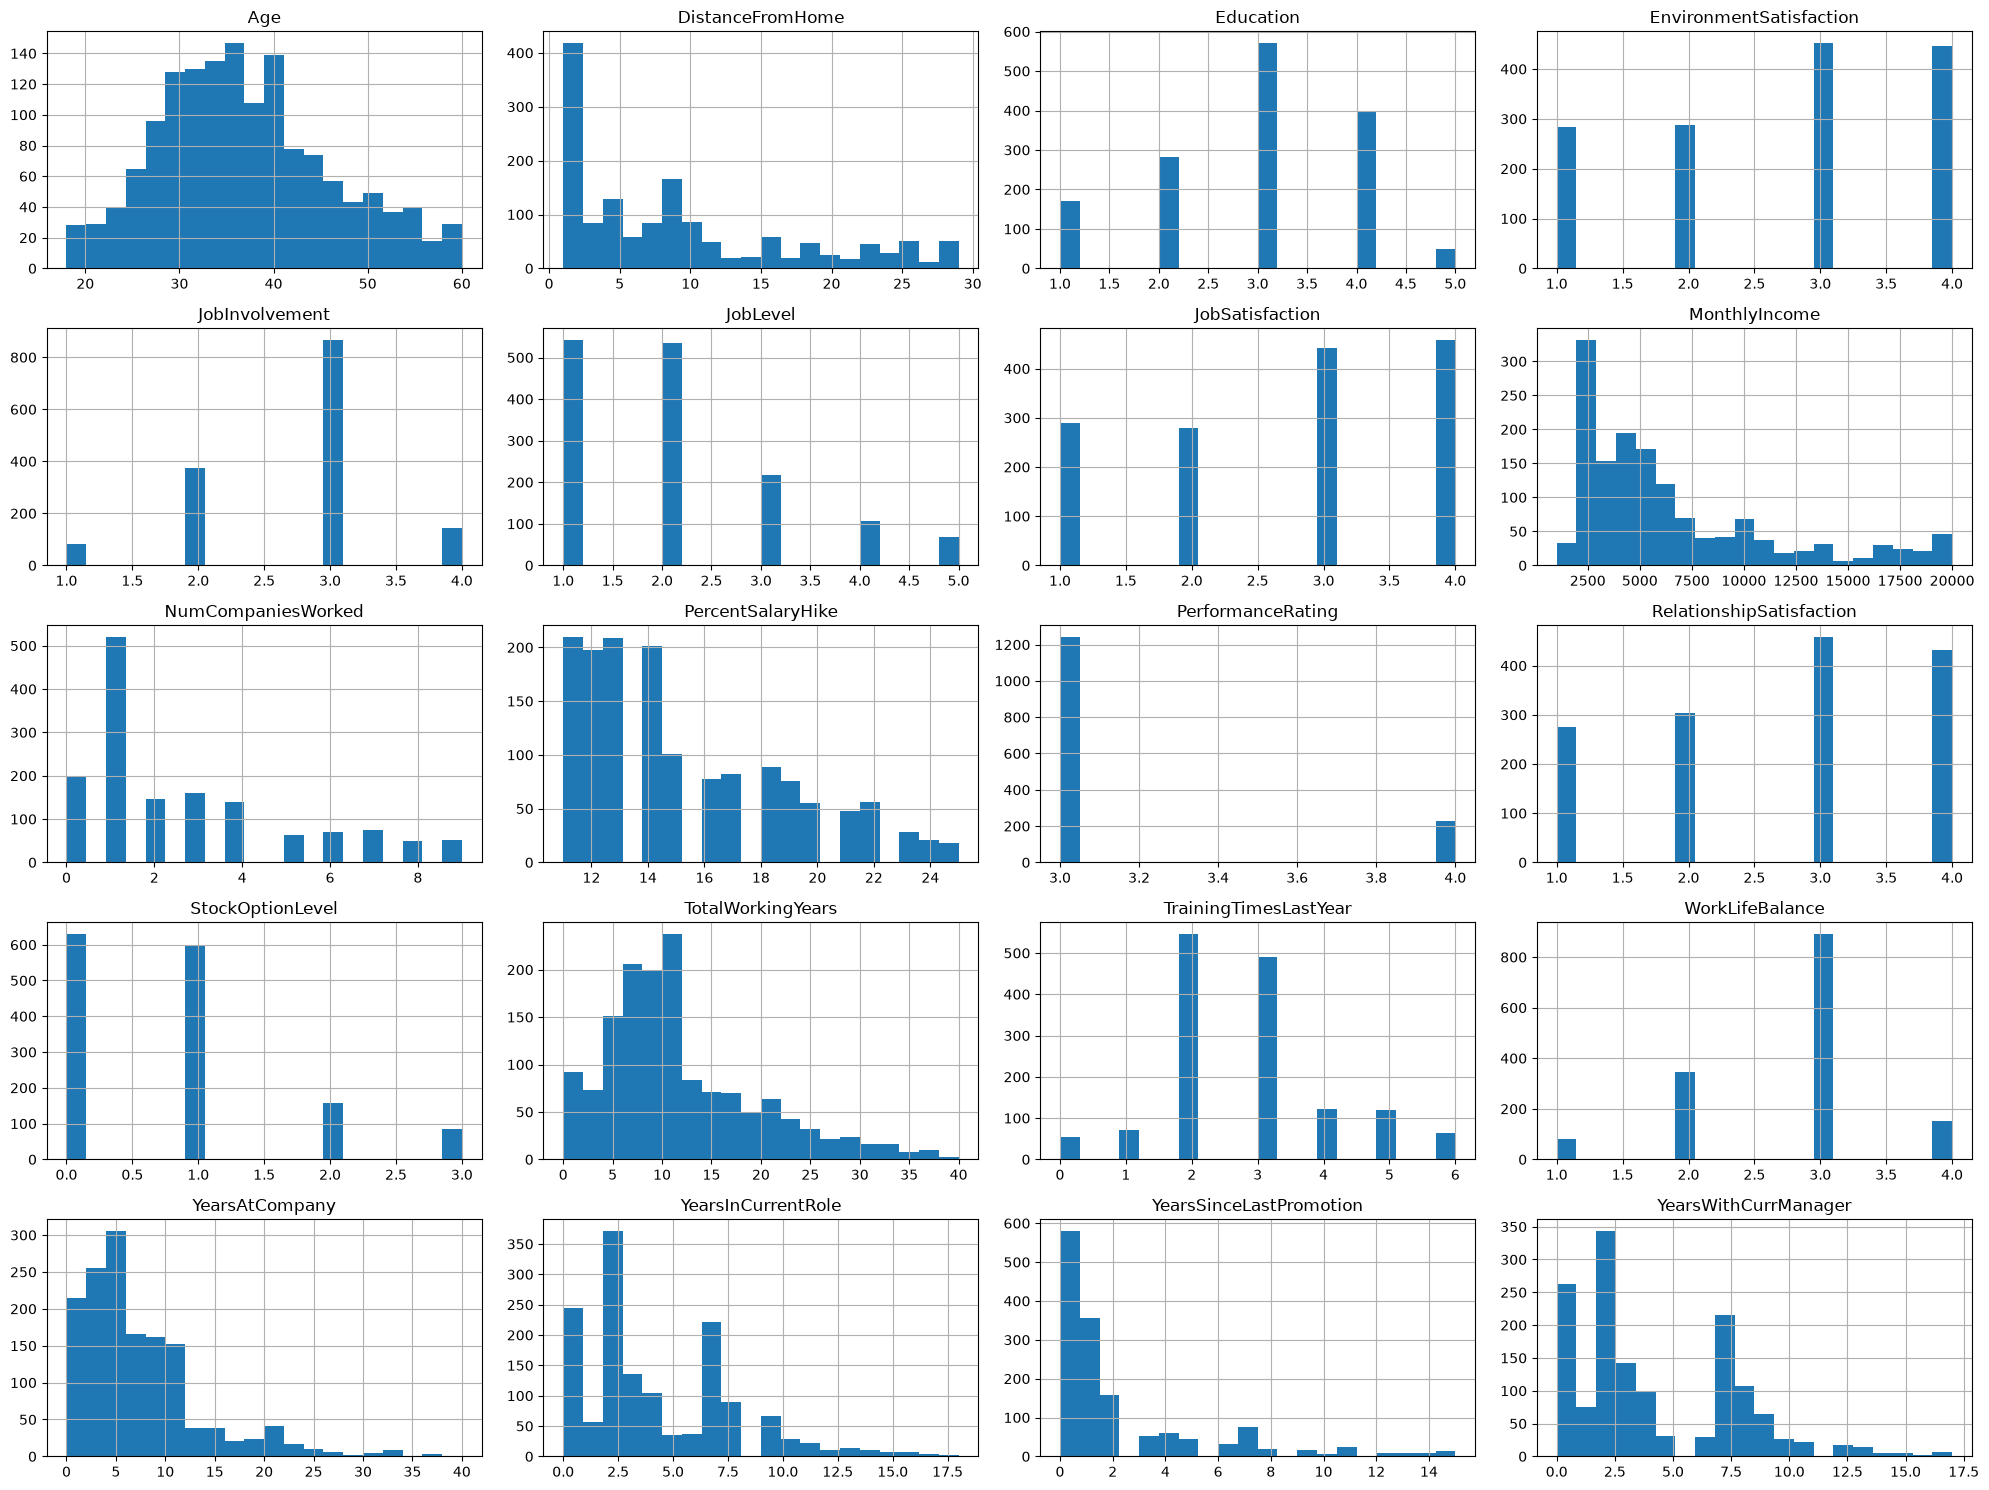

In [12]:
df.hist(figsize=(20,15),bins=20)
plt.tight_layout()
plt.show()

By the following histogram plottings of the numeric columns above we can conclude that

*   In the `age` graph we can clearly see that it is a normal distribution which is a very good sign for the company as the most number of employees belong to the age group of `30-40`. This indicates that the majority of the workforce are in their peak stage of career as they are still ambitious and have enough experience to make good decisions.
*   The salary range of `$2000-$3000` is the most paid salary as nearly `300+` employees earn in this range and also a lot of employees earn between `$3000-$7000`. Overall most number of employee fall under the salary bracket of `$2000-$7000` and consist of the major workforce of the company.

*   The total `working years` of the employees range from `0-40` where most employees are in the range of `0-15`. Employees having a work experience of `10-12` years constitute the major workforce and it is really beneficial to have them.


*   A lot of employees have been promoted very recently in last 2 years and we can also see that a lot of employees have been in this company from past `10 years` where a major chunk of employees have been since `5 years` and it is great that promotions have been done really well within the past 2 years








The above plots of `histogram `did show us a lot of distributions but we couldn't properly analyse histograms showing `discrete plottings` . So to counter this we will make a `countplot` and get the exact number of employees under each rating . It will involve columns based on **Satisfaction**, **Education**, **Performance rating** and **Work-Life-Balance** etc.
We will additionaly also run a `np.floor` to round of decimal values to integers for smooth plottings and convert the `numeric values` to `ordinal values`. 

In [13]:
#Satisfaction based columns mapped according to the official company data
sat_col = ['EnvironmentSatisfaction','JobInvolvement','JobSatisfaction','RelationshipSatisfaction']
sat_map = {1:'Low', 2:'Medium', 3:'High', 4:'Very High'}
for i in sat_col:
    df[f'{i}_label'] = np.floor(df[i]+0.5).astype('int64').map(sat_map) #np.floor is used to round of any decimal values present in dataset to prevent inconsistency

#Education based columns mapped according to the official company data
edu_map = {1:'Below College', 2:'College', 3:'Bachelor', 4:'Master', 5:'Doctor'}
df['Education_label'] = np.floor(df['Education']+0.5).astype('int64').map(edu_map)

#Perfornamce based columns mapped according to the official company data
per_map = {1:'Low', 2:'Good', 3:'Excellent', 4:'Outstanding'}
df['PerformanceRating_label'] = np.floor(df['PerformanceRating']+0.5).astype('int64').map(per_map)

#Work Life Balance based columns mapped according to the official company data
bal_map = {1:'Bad', 2:'Good', 3:'Better', 4:'Best'}
df['WorkLifeBalance_label'] = np.floor(df['WorkLifeBalance']+0.5).astype('int64').map(bal_map)


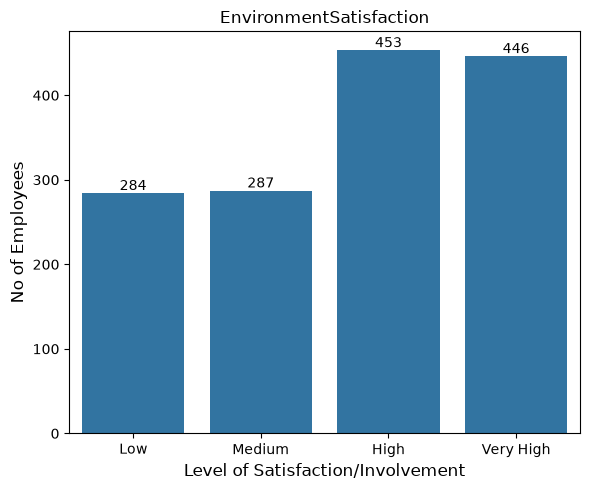

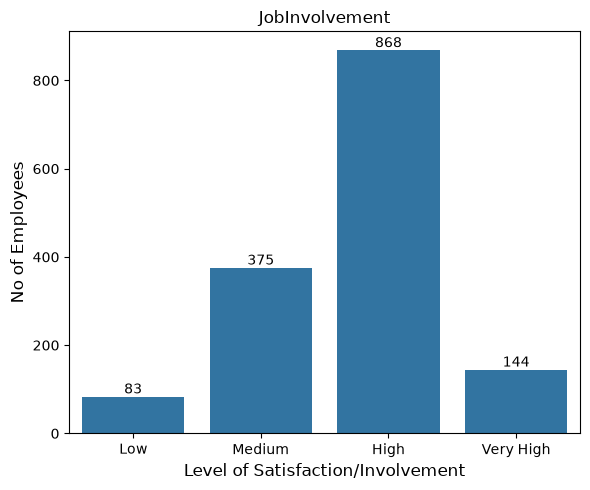

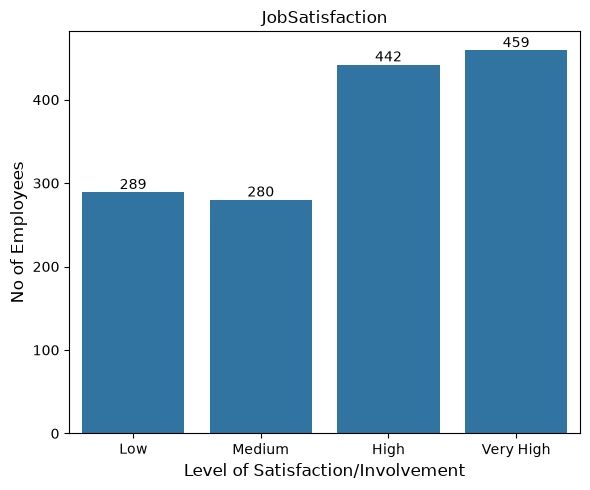

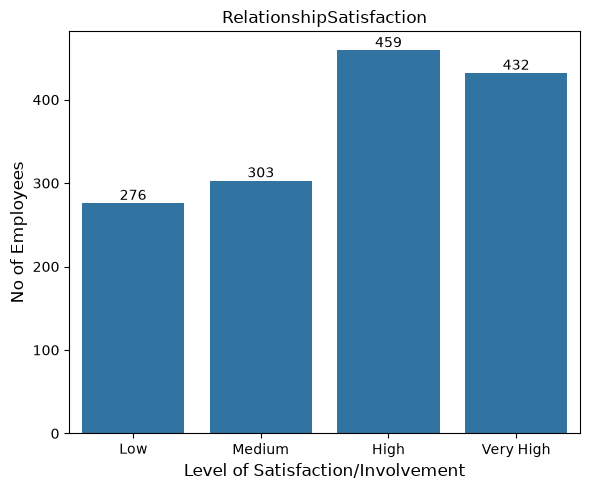

In [14]:
# For Satisfaction based plots
sat_order = ['Low', 'Medium', 'High', 'Very High']
for i in sat_col :
    plt.figure(figsize=(6, 5))
    graph = sns.countplot(data=df, x=(f'{i}_label'), order=sat_order)
    graph.bar_label(graph.containers[0])
    plt.title(f'{i}')
    plt.xlabel('Level of Satisfaction/Involvement',fontsize=12)
    plt.ylabel('No of Employees', fontsize=12)
    plt.tight_layout()
    plt.show()